In [ ]:
# Instalar 7zip
!apt-get install -y p7zip-full

# Crear carpeta de destino
!mkdir -p /content/zenodo_sharp

# Extraer el contenido del ZIP
!7z x "/content/zenodo_solar_flare_dataset.zip" -o"/content/zenodo_sharp/" -y


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
p7zip-full is already the newest version (16.02+dfsg-8).
0 upgraded, 0 newly installed, 0 to remove and 41 not upgraded.

7-Zip [64] 16.02 : Copyright (c) 1999-2016 Igor Pavlov : 2016-05-21
p7zip Version 16.02 (locale=en_US.UTF-8,Utf16=on,HugeFiles=on,64 bits,2 CPUs Intel(R) Xeon(R) CPU @ 2.20GHz (406F0),ASM,AES-NI)

Scanning the drive for archives:
  0M Scan /content/                   1 file, 112721920 bytes (108 MiB)

Extracting archive: /content/zenodo_solar_flare_dataset.zip

ERRORS:
Unexpected end of archive

--
Path = /content/zenodo_solar_flare_dataset.zip
Type = zip
ERRORS:
Unexpected end of archive
Physical Size = 127573285

  0%      5% 1 - zenodo_upload/training_data_C_48.csv                                              10% 1 - zenodo_upload/tra

In [ ]:
import os
os.listdir("/content/zenodo_sharp")
import os

for root, dirs, files in os.walk("/content/zenodo_sharp"):
    for f in files:
        if f.endswith(".csv"):
            print(os.path.join(root, f))


/content/zenodo_sharp/zenodo_upload/training_data_M_24.csv
/content/zenodo_sharp/zenodo_upload/testing_data_M5_48.csv
/content/zenodo_sharp/zenodo_upload/testing_data_C_72.csv
/content/zenodo_sharp/zenodo_upload/training_data_M5_48.csv
/content/zenodo_sharp/zenodo_upload/testing_data_M_24.csv
/content/zenodo_sharp/zenodo_upload/training_data_C_24.csv
/content/zenodo_sharp/zenodo_upload/training_data_M_48.csv
/content/zenodo_sharp/zenodo_upload/training_data_C_72.csv
/content/zenodo_sharp/zenodo_upload/training_data_M5_24.csv
/content/zenodo_sharp/zenodo_upload/testing_data_C_48.csv
/content/zenodo_sharp/zenodo_upload/training_data_M_72.csv
/content/zenodo_sharp/zenodo_upload/testing_data_M_72.csv
/content/zenodo_sharp/zenodo_upload/training_data_C_48.csv
/content/zenodo_sharp/zenodo_upload/testing_data_M_48.csv
/content/zenodo_sharp/zenodo_upload/testing_data_C_24.csv
/content/zenodo_sharp/zenodo_upload/testing_data_M5_24.csv
/content/zenodo_sharp/zenodo_upload/testing_data_M5_72.csv


In [ ]:
import pandas as pd
import glob

files = glob.glob("/content/zenodo_sharp/zenodo_upload/training_data_*.csv")
dfs = [pd.read_csv(f) for f in files]
df_big = pd.concat(dfs, ignore_index=True)
print(df_big.shape)


(1545127, 13)


In [ ]:
# Celda 1: limpiar df_big
USE_COLS = [
    "DATE__OBS","USFLUX","TOTUSJH","TOTUSJZ","MEANALP","R_VALUE",
    "TOTPOT","SAVNCPP","AREA_ACR","ABSNJZH","HARPNUM","NOAA_AR"
]

# filtra a las columnas que existan
cols_av = [c for c in USE_COLS if c in df_big.columns]
df = df_big[cols_av].copy()
del df_big  # libera RAM

# fecha
df["dt"] = pd.to_datetime(df["DATE__OBS"], utc=True, errors="coerce")
df = df.dropna(subset=["dt"]).drop(columns=["DATE__OBS"], errors="ignore")

# numéricos
num_cols = [c for c in df.columns if c not in ("dt","HARPNUM","NOAA_AR")]
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.sort_values("dt").reset_index(drop=True)
print("df shape:", df.shape)
df.head(2)


df shape: (1190366, 12)


,USFLUX,TOTUSJH,TOTUSJZ,MEANALP,R_VALUE,TOTPOT,SAVNCPP,AREA_ACR,ABSNJZH,HARPNUM,NOAA_AR,dt
0,-0.785468,-0.839834,-0.861356,-0.256507,0.523268,-0.807509,-0.807447,-0.866791,-0.840485,8932,13180,2022-12-30 09:48:00+00:00
1,-0.785468,-0.839834,-0.861356,-0.256507,0.523268,-0.807509,-0.807447,-0.866791,-0.840485,8932,13180,2022-12-30 09:48:00+00:00


In [ ]:
cmes = pd.read_csv("soho_cme_catalog.csv.gz")
cmes.head()


,Date,Time,CentralPA,Width,LinearSpeed,InitSpeed,FinalSpeed,Speed20R,Accel,Mass,KineticEnergy,MPA,Remarks,Datetime
0,1996/01/11,00:14:36,267.0,18,499.0,571.0,426.0,0.0,-64.3,NaN,NaN,272,Only C3,1996-01-11 00:14:36
1,1996/01/13,22:08:30,265.0,16,290.0,278.0,303.0,372.0,2.8,NaN,NaN,266,Only C3,1996-01-13 22:08:30
2,1996/01/15,07:01:10,262.0,43,525.0,600.0,454.0,0.0,-31.1,NaN,NaN,272,Only C3,1996-01-15 07:01:10
3,1996/01/22,03:11:01,105.0,37,267.0,401.0,130.0,0.0,-126.3,7.100000e+13,2.500000e+28,103,Very Poor Event; Only C3,1996-01-22 03:11:01
4,1996/01/26,09:16:19,90.0,27,262.0,254.0,271.0,322.0,1.9,3.000000e+14,1.000000e+29,90,Poor Event; Only C3,1996-01-26 09:16:19


In [ ]:
# Para el dataset SHARP
print("SHARP:", df["dt"].min(), "→", df["dt"].max())

# Para el dataset CME
cmes["Datetime"] = pd.to_datetime(cmes["Datetime"], errors="coerce", utc=True)
print("CME:", cmes["Datetime"].min(), "→", cmes["Datetime"].max())


SHARP: 2022-12-30 09:48:00+00:00 → 2025-02-25 16:48:00+00:00
CME: 1996-01-11 00:14:36+00:00 → 2025-06-30 12:12:05+00:00


In [ ]:
import pandas as pd

# Forzar la conversión a datetime, asegurando formato correcto y zona horaria UTC
cmes["Datetime"] = pd.to_datetime(cmes["Datetime"], errors="coerce", utc=True)

# Comprobar que se ha hecho bien
print("Tipo:", cmes["Datetime"].dtype)
print("Primeras fechas:", cmes["Datetime"].head())


Tipo: datetime64[ns, UTC]
Primeras fechas: 0   1996-01-11 00:14:36+00:00
1   1996-01-13 22:08:30+00:00
2   1996-01-15 07:01:10+00:00
3   1996-01-22 03:11:01+00:00
4   1996-01-26 09:16:19+00:00
Name: Datetime, dtype: datetime64[ns, UTC]


In [ ]:
# 1) Recorta CMEs al rango de SHARP
t0, t1 = df["dt"].min(), df["dt"].max()
cmes_cut = cmes[(cmes["Datetime"] >= t0) & (cmes["Datetime"] <= t1)].copy()

# 2) Ordena y une por proximidad temporal
df_sorted   = df.sort_values("dt").copy()
cmes_sorted = cmes_cut.sort_values("Datetime").copy()

merged_near = pd.merge_asof(
    df_sorted, cmes_sorted,
    left_on="dt", right_on="Datetime",
    direction="nearest",
    tolerance=pd.Timedelta("6h")  # ajusta la ventana
)


merged_near = merged_near.dropna(subset=["Datetime"])
print(merged_near.shape)

merged_near.head()

(1043143, 26)


,USFLUX,TOTUSJH,TOTUSJZ,MEANALP,R_VALUE,TOTPOT,SAVNCPP,AREA_ACR,ABSNJZH,HARPNUM,...,LinearSpeed,InitSpeed,FinalSpeed,Speed20R,Accel,Mass,KineticEnergy,MPA,Remarks,Datetime
0,-0.785468,-0.839834,-0.861356,-0.256507,0.523268,-0.807509,-0.807447,-0.866791,-0.840485,8932,...,515.0,643.0,377.0,0.0,-18.2,1.100000e+15,1.400000e+30,174.0,Poor Event,2022-12-30 11:36:05+00:00
1,-0.785468,-0.839834,-0.861356,-0.256507,0.523268,-0.807509,-0.807447,-0.866791,-0.840485,8932,...,515.0,643.0,377.0,0.0,-18.2,1.100000e+15,1.400000e+30,174.0,Poor Event,2022-12-30 11:36:05+00:00
2,-0.786910,-0.846738,-0.863895,-0.250682,0.534643,-0.802013,-0.844877,-0.866696,-0.887580,8932,...,515.0,643.0,377.0,0.0,-18.2,1.100000e+15,1.400000e+30,174.0,Poor Event,2022-12-30 11:36:05+00:00
3,-0.786910,-0.846738,-0.863895,-0.250682,0.534643,-0.802013,-0.844877,-0.866696,-0.887580,8932,...,515.0,643.0,377.0,0.0,-18.2,1.100000e+15,1.400000e+30,174.0,Poor Event,2022-12-30 11:36:05+00:00
4,-0.789024,-0.848784,-0.866034,-0.246060,0.558083,-0.802209,-0.905526,-0.867106,-0.923891,8932,...,515.0,643.0,377.0,0.0,-18.2,1.100000e+15,1.400000e+30,174.0,Poor Event,2022-12-30 11:36:05+00:00


In [ ]:
# Define cmes_ener by filtering cmes based on KineticEnergy, LinearSpeed, and Width
cmes_ener = cmes[
    (cmes["LinearSpeed"] > 500) & (cmes["Width"] > 70)
].copy()
print("cmes_ener shape:", cmes_ener.shape)

cmes_ener shape: (1692, 14)


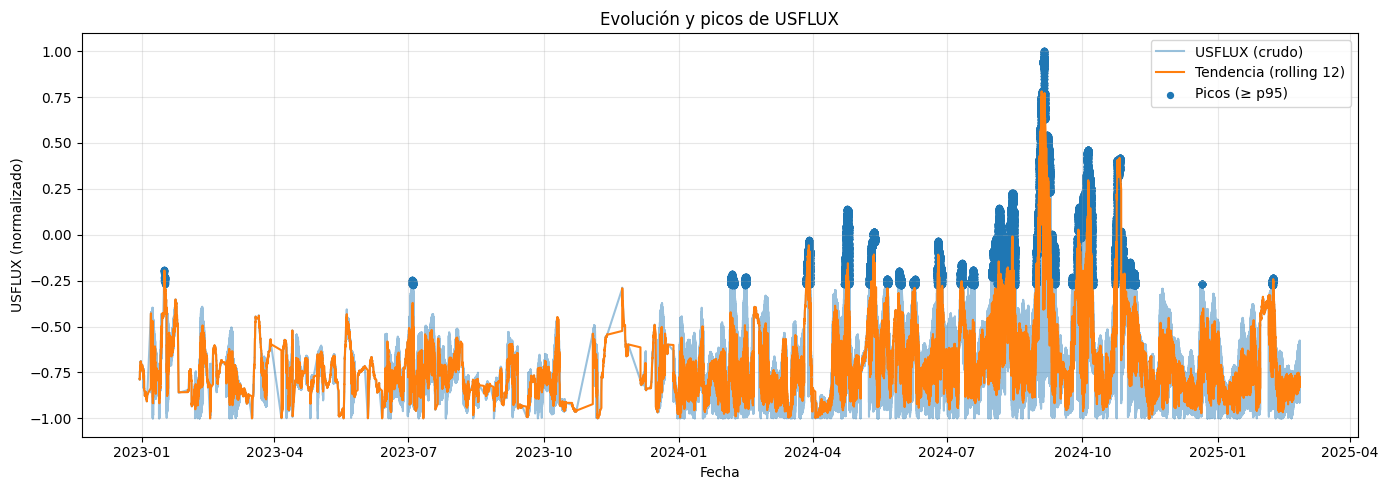

Percentil 95 (pico) USFLUX: -0.2721 | Nº picos: 52159


In [ ]:
# EXPLORATORIO: Picos de USFLUX
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Copia
sharp_explo = merged_near[['dt','USFLUX']].dropna().copy()
sharp_explo['dt'] = pd.to_datetime(sharp_explo['dt'], errors='coerce')
sharp_explo = sharp_explo.sort_values('dt')

# Suavizado simple (ventana de 12 muestras)
sharp_explo['USFLUX_smooth'] = sharp_explo['USFLUX'].rolling(window=12, min_periods=1).mean()

# Umbral de picos
q95 = float(np.quantile(sharp_explo['USFLUX'].dropna(), 0.95))
peaks = sharp_explo[sharp_explo['USFLUX'] >= q95]

plt.figure(figsize=(14,5))
plt.plot(sharp_explo['dt'], sharp_explo['USFLUX'], label='USFLUX (crudo)', alpha=0.45)
plt.plot(sharp_explo['dt'], sharp_explo['USFLUX_smooth'], label='Tendencia (rolling 12)', linewidth=1.5)
plt.scatter(peaks['dt'], peaks['USFLUX'], label='Picos (≥ p95)', s=18)
plt.title('Evolución y picos de USFLUX')
plt.xlabel('Fecha'); plt.ylabel('USFLUX (normalizado)')
plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout()
plt.show()

print(f"Percentil 95 (pico) USFLUX: {q95:.4f} | Nº picos: {len(peaks)}")


In [ ]:
import pandas as pd
import numpy as np

df = df.sort_values("dt").reset_index(drop=True)
cmes_ener = cmes_ener.sort_values("Datetime").reset_index(drop=True)

def label_for_H(df_base, cmes_base, H_hours):
    H = pd.Timedelta(hours=H_hours)
    # asignar próxima CME energética
    nxt = pd.merge_asof(
        df_base[["dt"]],
        cmes_base[["Datetime"]].rename(columns={"Datetime": "next_dt"}),
        left_on="dt",
        right_on="next_dt",
        direction="forward",
        tolerance=pd.Timedelta("10D")
    )
    within = (
        nxt["next_dt"].notna() &
        ((nxt["next_dt"] - df_base["dt"]) > pd.Timedelta(0)) &
        ((nxt["next_dt"] - df_base["dt"]) <= H)
    )
    return within.astype(int)

# probamos horizontes desde 6 h hasta 120 h
Hs = np.arange(3, 121, 7)
prev = {}
for H in Hs:
    y_tmp = label_for_H(df, cmes_ener, H)
    prev[H] = y_tmp.mean()

target = 0.15
best_H = min(prev, key=lambda h: abs(prev[h] - target))
print("Horizonte elegido:", best_H, "horas  |  prevalencia≈", round(prev[best_H],3))


Horizonte elegido: 10 horas  |  prevalencia≈ 0.204


In [ ]:
# Aseguramos orden temporal
df = df.sort_values("dt").reset_index(drop=True)
cmes_ener = cmes_ener.sort_values("Datetime").reset_index(drop=True)

# Unimos la próxima CME energética a cada punto SHARP
next_ener = pd.merge_asof(
    df[["dt"]].sort_values("dt"),
    cmes_ener[["Datetime"]].rename(columns={"Datetime": "next_ener_dt"}),
    left_on="dt",
    right_on="next_ener_dt",
    direction="forward",
    tolerance=pd.Timedelta("7D")  # tolerancia amplia para encontrar "siguiente"
)

df_lab = df.join(next_ener["next_ener_dt"])
H = pd.Timedelta(hours=10)

# Etiqueta binaria
df_lab["CME_next"] = (
    (df_lab["next_ener_dt"].notna()) &
    (df_lab["next_ener_dt"] - df_lab["dt"] > pd.Timedelta(0)) &
    (df_lab["next_ener_dt"] - df_lab["dt"] <= H)
).astype(int)

print("Positivos:", int(df_lab["CME_next"].sum()))
print("Proporción:", round(float(df_lab["CME_next"].mean()), 3))
df_lab[["dt", "next_ener_dt", "CME_next"]].head(10)


Positivos: 212570
Proporción: 0.204


,dt,next_ener_dt,CME_next
0,2022-12-30 09:48:00+00:00,2022-12-30 11:36:05+00:00,1
1,2022-12-30 09:48:00+00:00,2022-12-30 11:36:05+00:00,1
2,2022-12-30 10:00:00+00:00,2022-12-30 11:36:05+00:00,1
3,2022-12-30 10:00:00+00:00,2022-12-30 11:36:05+00:00,1
4,2022-12-30 10:12:00+00:00,2022-12-30 11:36:05+00:00,1
5,2022-12-30 10:12:00+00:00,2022-12-30 11:36:05+00:00,1
6,2022-12-30 10:24:00+00:00,2022-12-30 11:36:05+00:00,1
7,2022-12-30 10:24:00+00:00,2022-12-30 11:36:05+00:00,1
8,2022-12-30 10:36:00+00:00,2022-12-30 11:36:05+00:00,1
9,2022-12-30 10:36:00+00:00,2022-12-30 11:36:05+00:00,1


In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import RobustScaler

# y binaria ya creada:
y = df_lab["CME_next"].astype(int).values

# Selección de features
FEAT_COLS = [c for c in df.columns if c not in ("dt","HARPNUM","NOAA_AR")]
X = df[FEAT_COLS].copy()
for c in FEAT_COLS:
    X[c] = pd.to_numeric(X[c], errors="coerce")

# Resampleo a 1h
Xh = (X.set_index(df["dt"])
        .sort_index()
        .resample("1H").median())
yh = (pd.Series(y, index=df["dt"])
        .sort_index()
        .resample("1H").max())

# Alinear índices
common_idx = Xh.index.intersection(yh.index)
Xh = Xh.reindex(common_idx)
yh = yh.reindex(common_idx).fillna(0).astype(int)

# Rellenos y escalado
Xh = Xh.ffill(limit=6).bfill(limit=6)               # hasta ±6h
Xh = Xh.fillna(Xh.median(numeric_only=True)).fillna(0)

scaler = RobustScaler()
Xh_scaled = pd.DataFrame(scaler.fit_transform(Xh), index=Xh.index, columns=Xh.columns)

# Secuencias LSTM: 24h de historia
WINDOW = 24

def build_sequences(X_df, y_ser, window):
    vals = X_df.values
    yv = y_ser.values
    X_seq, y_seq, t_seq = [], [], []
    for i in range(window, len(X_df)):
        X_seq.append(vals[i-window:i])
        y_seq.append(yv[i])
        t_seq.append(X_df.index[i])
    return np.array(X_seq, dtype=np.float32), np.array(y_seq, dtype=np.int8), np.array(t_seq)

X_seq, y_seq, t_seq = build_sequences(Xh_scaled, yh, WINDOW)
print("X_seq:", X_seq.shape, "| pos%:", float(y_seq.mean()))


/tmp/ipython-input-621786562.py:18: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample("1H").median())
/tmp/ipython-input-621786562.py:21: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample("1H").max())


X_seq: (18896, 24, 23) | pos%: 0.15754657070279424


In [ ]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

n = len(X_seq)
i_tr = int(n*0.70)
i_va = int(n*0.85)

X_tr, y_tr = X_seq[:i_tr], y_seq[:i_tr]
X_va, y_va = X_seq[i_tr:i_va], y_seq[i_tr:i_va]
X_te, y_te = X_seq[i_va:], y_seq[i_va:]

print("Train:", X_tr.shape, "pos%:", float(y_tr.mean()))
print("Val:  ", X_va.shape, "pos%:", float(y_va.mean()))
print("Test: ", X_te.shape, "pos%:", float(y_te.mean()))

# Pesos de clase
unique_tr = np.unique(y_tr)
if set(unique_tr) == {0,1}:
    cw_vals = compute_class_weight('balanced', classes=np.array([0,1]), y=y_tr)
    class_weight = {0: float(cw_vals[0]), 1: float(cw_vals[1])}
else:
    # Fallback con prevalencia global
    p_all = float(y_seq.mean())
    if p_all == 0.0:
        raise ValueError("No hay positivos tras el etiquetado; revisa HOURS.")
    class_weight = {0: 0.5/(1-p_all+1e-9), 1: 0.5/(p_all+1e-9)}
    print("⚠️ Usando pesos globales:", {k: round(v,3) for k,v in class_weight.items()})

class_weight


Train: (13227, 24, 23) pos%: 0.14878657291902925
Val:   (2834, 24, 23) pos%: 0.21418489767113622
Test:  (2835, 24, 23) pos%: 0.14179894179894179


{0: 0.5873967492672528, 1: 3.3605182926829267}

In [ ]:
# Partimos de Xh (1h) y yh de tu Celda 3 antes del escalado:
Xh_base = Xh.copy()

def add_feats(df):
    out = df.copy()
    for w in [6,12,24]:
        out[[f"{c}_ma{w}" for c in df.columns]] = df.rolling(f"{w}H").mean()
        out[[f"{c}_sd{w}" for c in df.columns]] = df.rolling(f"{w}H").std()
        out[[f"{c}_min{w}" for c in df.columns]] = df.rolling(f"{w}H").min()
        out[[f"{c}_max{w}" for c in df.columns]] = df.rolling(f"{w}H").max()
    # derivadas (cambio 1h y 6h)
    out[[f"{c}_d1"  for c in df.columns]] = df.diff(1)
    out[[f"{c}_d6h" for c in df.columns]] = df.diff(6)
    # zscore 24h
    for c in df.columns:
        m = df[c].rolling("24H").mean()
        s = df[c].rolling("24H").std()
        out[f"{c}_z24"] = (df[c]-m)/(s+1e-6)
    return out

Xh_enh = add_feats(Xh_base).ffill(limit=24).bfill(limit=24)
Xh_enh = Xh_enh.fillna(Xh_enh.median(numeric_only=True)).fillna(0)

from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
Xh_scaled = pd.DataFrame(scaler.fit_transform(Xh_enh), index=Xh_enh.index, columns=Xh_enh.columns)


/tmp/ipython-input-3170655060.py:7: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  out[[f"{c}_ma{w}" for c in df.columns]] = df.rolling(f"{w}H").mean()
/tmp/ipython-input-3170655060.py:8: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  out[[f"{c}_sd{w}" for c in df.columns]] = df.rolling(f"{w}H").std()
/tmp/ipython-input-3170655060.py:9: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  out[[f"{c}_min{w}" for c in df.columns]] = df.rolling(f"{w}H").min()
/tmp/ipython-input-3170655060.py:10: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  out[[f"{c}_max{w}" for c in df.columns]] = df.rolling(f"{w}H").max()
/tmp/ipython-input-3170655060.py:7: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  out[[f"{c}_ma{w}" for c in df.columns]] = df

In [ ]:
# split temporal
# oversample positivos en TRAIN hasta 1:1
import numpy as np
pos = np.where(y_tr==1)[0]
neg = np.where(y_tr==0)[0]
rng = np.random.default_rng(42)
neg_sample = rng.choice(neg, size=len(pos), replace=False if len(neg)>=len(pos) else True)

idx_bal = np.concatenate([pos, neg_sample])
rng.shuffle(idx_bal)

X_tr_bal = X_tr[idx_bal]
y_tr_bal = y_tr[idx_bal]

print("Balance train:", y_tr_bal.mean())  # ~0.5


Balance train: 0.5


In [ ]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Input(shape=(X_tr_bal.shape[1], X_tr_bal.shape[2])),  # (timesteps, features)
    layers.LSTM(64, return_sequences=True),
    layers.Dropout(0.3),
    layers.LSTM(32),
    layers.Dropout(0.3),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])


In [ ]:
import tensorflow as tf
from tensorflow import keras

def focal_loss(gamma=2.0, alpha=0.50):  # menos sesgo a la clase 1
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        eps = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, eps, 1-eps)
        pt = tf.where(tf.equal(y_true,1), y_pred, 1-y_pred)
        w  = tf.where(tf.equal(y_true,1), alpha, 1-alpha)
        return -tf.reduce_mean(w * tf.pow(1-pt, gamma) * tf.math.log(pt))
    return loss

# Métricas útiles
metrics = [
    keras.metrics.Precision(name="precision"),
    keras.metrics.Recall(name="recall"),
    keras.metrics.AUC(curve="PR", name="auprc"),
    keras.metrics.AUC(curve="ROC", name="auroc"),
]

model.compile(
    optimizer=keras.optimizers.Adam(7e-4),
    loss=focal_loss(gamma=2.0, alpha=0.50),
    metrics=metrics
)


cbs = [
    keras.callbacks.ReduceLROnPlateau(monitor="val_auprc", mode="max",
                                      factor=0.5, patience=3, verbose=1),
    keras.callbacks.EarlyStopping(monitor="val_auprc", mode="max",
                                  patience=6, restore_best_weights=True, verbose=1)
]

hist = model.fit(
    X_tr_bal, y_tr_bal,
    validation_data=(X_va, y_va),
    epochs=40,
    batch_size=128,
    verbose=1,
)


Epoch 1/40
31/31 ━━━━━━━━━━━━━━━━━━━━ 14s 248ms/step - auprc: 0.5382 - auroc: 0.5706 - loss: 0.0875 - precision: 0.5410 - recall: 0.7348 - val_auprc: 0.2106 - val_auroc: 0.4959 - val_loss: 0.0852 - val_precision: 0.2045 - val_recall: 0.3773
Epoch 2/40
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 153ms/step - auprc: 0.6740 - auroc: 0.7070 - loss: 0.0793 - precision: 0.6294 - recall: 0.7232 - val_auprc: 0.2321 - val_auroc: 0.5248 - val_loss: 0.0855 - val_precision: 0.2352 - val_recall: 0.4580
Epoch 3/40
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 174ms/step - auprc: 0.7242 - auroc: 0.7519 - loss: 0.0737 - precision: 0.6587 - recall: 0.7379 - val_auprc: 0.2338 - val_auroc: 0.5132 - val_loss: 0.0956 - val_precision: 0.2288 - val_recall: 0.5321
Epoch 4/40
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 182ms/step - auprc: 0.7658 - auroc: 0.8025 - loss: 0.0675 - precision: 0.6942 - recall: 0.7756 - val_auprc: 0.2345 - val_auroc: 0.5125 - val_loss: 0.0952 - val_precision: 0.2254 - val_recall: 0.5354
Epoch 5/40
31/31 ━━━━━━━━━━━━━━━━━━━━ 8

In [ ]:
import numpy as np
from sklearn.metrics import (
    precision_recall_curve, classification_report, confusion_matrix, roc_auc_score
)
from sklearn.metrics import recall_score

def pick_threshold_by_target_recall(y_true, p, target_recall=0.45, prefer="specificity"):
    """
    prefer: "specificity"  -> maximiza recall de clase 0
            "balanced_acc" -> maximiza (recall0+recall1)/2
            "precision"    -> maximiza precisión con recall1>=target
    """
    prec, rec, thr = precision_recall_curve(y_true, p)
    # precision_recall_curve devuelve 'thr' de longitud len(prec)-1
    # Asociamos cada (prec,rec) con su umbral correspondiente
    thr_full = np.r_[thr[0]-1e-6, thr]
    mask = rec >= target_recall
    idxs = np.where(mask)[0]
    if len(idxs) == 0:
        # Si no hay recall suficiente, relajamos al mejor recall posible
        idx = np.argmax(rec)
        return float(thr_full[idx]), float(prec[idx]), float(rec[idx])
    # Evaluar criterio secundario
    best_idx = None
    best_score = -np.inf
    for i in idxs:
        t = thr_full[i]
        yhat = (p >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, yhat).ravel()
        rec1 = tp / (tp + fn + 1e-9)
        rec0 = tn / (tn + fp + 1e-9)   # especificidad
        bal = 0.5 * (rec0 + rec1)
        if prefer == "specificity":
            score = rec0
        elif prefer == "balanced_acc":
            score = bal
        else:  # precision
            pr = tp / (tp + fp + 1e-9)
            score = pr
        if score > best_score:
            best_score = score
            best_idx = i
    return float(thr_full[best_idx]), float(prec[best_idx]), float(rec[best_idx])

# Validación: fijamos el umbral
p_va = model.predict(X_va, verbose=0).ravel()
thr_star, P_va, R_va = pick_threshold_by_target_recall(y_va, p_va,
                                                       target_recall=0.45,
                                                       prefer="specificity")
print(f"[VAL] thr*={thr_star:.3f} | P={P_va:.3f} | R={R_va:.3f}")

# Test: aplicamos el umbral y reportamos ambas clases
p_te = model.predict(X_te, verbose=0).ravel()
yhat_te = (p_te >= thr_star).astype(int)

# Métricas por clase
tn, fp, fn, tp = confusion_matrix(y_te, yhat_te).ravel()
recall1 = tp / (tp + fn + 1e-9)             # sensibilidad (clase 1)
recall0 = tn / (tn + fp + 1e-9)             # especificidad (clase 0)
prec1   = tp / (tp + fp + 1e-9)
prec0   = tn / (tn + fn + 1e-9)
bal_acc = 0.5*(recall0 + recall1)

print("\n=== TEST REPORT (umbral fijado por validación) ===")
print(classification_report(y_te, yhat_te, digits=3))
print("Confusion matrix [tn fp; fn tp]:")
print(np.array([[tn, fp],[fn, tp]]))
print(f"\nExtra:\n  Recall_1 (sensibilidad) = {recall1:.3f}"
      f"\n  Recall_0 (especificidad)  = {recall0:.3f}"
      f"\n  Balanced Accuracy         = {bal_acc:.3f}")

# ROC/PR AUC con scores
try:
    auroc = roc_auc_score(y_te, p_te)
    print(f"AUROC (scores) = {auroc:.3f}")
except Exception:
    pass


[VAL] thr*=0.235 | P=0.231 | R=0.451

=== TEST REPORT (umbral fijado por validación) ===
              precision    recall  f1-score   support

           0      0.860     0.443     0.585      2433
           1      0.143     0.562     0.228       402

    accuracy                          0.460      2835
   macro avg      0.501     0.503     0.406      2835
weighted avg      0.758     0.460     0.534      2835

Confusion matrix [tn fp; fn tp]:
[[1078 1355]
 [ 176  226]]

Extra:
  Recall_1 (sensibilidad) = 0.562
  Recall_0 (especificidad)  = 0.443
  Balanced Accuracy         = 0.503
AUROC (scores) = 0.485


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers


has_tab = all(v in globals() for v in ["Xtab_tr","Xtab_va","Xtab_te"])
print("Usando entrada tabular:", has_tab)

# Bias inicial según prevalencia (para no arrancar en "todo 0")
pos_rate_tr = float(np.mean(y_tr))
init_bias = float(np.log((pos_rate_tr + 1e-9) / (1.0 - pos_rate_tr + 1e-9)))
print(f"pos_rate_tr={pos_rate_tr:.4f} | init_bias={init_bias:.3f}")

def ConvBlock(x, filters, k, d=1, drop=0.0, l2=1e-4):
    h = layers.Conv1D(filters, k, padding="same", dilation_rate=d,
                      kernel_regularizer=regularizers.l2(l2))(x)
    h = layers.BatchNormalization()(h)
    h = layers.ReLU()(h)
    if drop>0:
        h = layers.Dropout(drop)(h)
    return h

def ResBlock(x, filters, k, d=1, drop=0.0, l2=1e-4):
    h = ConvBlock(x, filters, k, d, drop, l2)
    h = layers.Conv1D(filters, k, padding="same", dilation_rate=d,
                      kernel_regularizer=regularizers.l2(l2))(h)
    h = layers.BatchNormalization()(h)
    # proyección si cambia dimensión
    if x.shape[-1] != filters:
        x = layers.Conv1D(filters, 1, padding="same")(x)
    h = layers.Add()([x, h])
    h = layers.ReLU()(h)
    return h

def build_cnn(seq_shape, tab_shape=None, lr=1e-3, drop=0.3, l2=1e-4):
    inp_seq = keras.Input(shape=seq_shape, name="seq")

    x = ConvBlock(inp_seq, 64, k=5, d=1, drop=0.1, l2=l2)
    x = ResBlock(x, 64, k=5, d=2, drop=0.1, l2=l2)
    x = layers.MaxPooling1D(pool_size=2)(x)

    x = ConvBlock(x, 128, k=3, d=1, drop=0.1, l2=l2)
    x = ResBlock(x, 128, k=3, d=2, drop=0.1, l2=l2)

    # Pooling dual (retiene picos y tendencia)
    gap = layers.GlobalAveragePooling1D()(x)
    gmp = layers.GlobalMaxPooling1D()(x)
    x = layers.Concatenate()([gap, gmp])

    if tab_shape is not None:
        inp_tab = keras.Input(shape=tab_shape, name="tab")
        t = layers.Dense(64, activation="relu")(inp_tab)
        t = layers.BatchNormalization()(t)
        t = layers.Dropout(drop)(t)
        x = layers.Concatenate()([x, t])
        inputs = [inp_seq, inp_tab]
    else:
        inputs = inp_seq

    x = layers.Dense(128, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(drop)(x)
    out = layers.Dense(1, activation="sigmoid",
                       bias_initializer=keras.initializers.Constant(init_bias))(x)

    model = keras.Model(inputs=inputs, outputs=out, name="cnn_cme_bias_dilated")

    loss = keras.losses.BinaryCrossentropy()

    model.compile(
        optimizer=keras.optimizers.Adam(lr),
        loss=loss,
        metrics=[
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
            keras.metrics.AUC(curve="PR", name="auprc"),
            keras.metrics.AUC(curve="ROC", name="auroc"),
        ],
    )
    return model

seq_shape = X_tr.shape[1:]
if has_tab:
    tab_shape = Xtab_tr.shape[1:]
    model = build_cnn(seq_shape, tab_shape, lr=1e-3, drop=0.3, l2=1e-4)
    tr_inputs = [X_tr, Xtab_tr]
    va_inputs = [X_va, Xtab_va]
    te_inputs = [X_te, Xtab_te]
else:
    model = build_cnn(seq_shape, None, lr=1e-3, drop=0.3, l2=1e-4)
    tr_inputs = X_tr
    va_inputs = X_va
    te_inputs = X_te

model.summary()


Usando entrada tabular: False
pos_rate_tr=0.1488 | init_bias=-1.744


Model: "cnn_cme_bias_dilated"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seq (InputLayer)    │ (None, 24, 23)    │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 24, 64)    │      7,424 │ seq[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 24, 64)    │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 24, 64)    │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 24, 64)    │          0 │ re_lu[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 24, 64)    │     20,544 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 64)    │        256 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 24, 64)    │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 24, 64)    │          0 │ re_lu_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 24, 64)    │     20,544 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 64)    │        256 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 24, 64)    │          0 │ dropout_2[0][0],  │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 24, 64)    │          0 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 12, 64)    │          0 │ re_lu_2[0][0]     │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 12, 128)   │     24,704 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 12, 128)   │        512 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 12, 128)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 12, 128)   │          0 │ re_lu_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 12, 128)   │     49,280 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 12, 128)   │        512 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_4 (ReLU)      │ (None, 12, 128)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 207,617 (811.00 KB)

 Trainable params: 206,209 (805.50 KB)

 Non-trainable params: 1,408 (5.50 KB)

In [ ]:
import numpy as np
from sklearn.utils import resample
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score

# UPSAMPLING 1:1

def make_balanced(X, y, Xtab=None, seed=42):
    rng = np.random.RandomState(seed)
    idx_pos = np.where(y==1)[0]
    idx_neg = np.where(y==0)[0]
    n_pos = len(idx_pos)
    n_neg = len(idx_neg)
    if n_pos==0 or n_neg==0:
        return X, y, Xtab
    if n_pos > n_neg:
        idx_neg_up = resample(idx_neg, replace=True, n_samples=n_pos, random_state=seed)
        idx_new = np.r_[idx_pos, idx_neg_up]
    else:
        idx_pos_up = resample(idx_pos, replace=True, n_samples=n_neg, random_state=seed)
        idx_new = np.r_[idx_pos_up, idx_neg]
    rng.shuffle(idx_new)
    if Xtab is None:
        return X[idx_new], y[idx_new], None
    else:
        return (X[idx_new], y[idx_new], Xtab[idx_new])

if has_tab:
    X_tr_bal, y_tr_bal, Xtab_tr_bal = make_balanced(X_tr, y_tr, Xtab_tr)
    tr_inputs_bal = [X_tr_bal, Xtab_tr_bal]
else:
    X_tr_bal, y_tr_bal, _ = make_balanced(X_tr, y_tr, None)
    tr_inputs_bal = X_tr_bal

print("Train shapes (balanced):", (X_tr_bal.shape, y_tr_bal.shape))

# class_weight
# al estar 1:1, ambos ~0.5; damos un pequeño plus al positivo para empujar recall₁ con corte 0.5
class_weight = {0: 1.0, 1: 1.2}
print("class_weight:", class_weight)

# Callbacks
cbs = [
    keras.callbacks.ReduceLROnPlateau(monitor="val_auprc", mode="max",
                                      factor=0.5, patience=3, verbose=1),
    keras.callbacks.EarlyStopping(monitor="val_auprc", mode="max",
                                  patience=6, restore_best_weights=True, verbose=1),
]

# Fit
hist = model.fit(
    tr_inputs_bal, y_tr_bal,
    validation_data=(va_inputs, y_va),
    epochs=20,
    batch_size=128,
    class_weight=class_weight,
    callbacks=cbs,
    verbose=1,
)

# Evaluación (corte fijo p>=0.5, SIN umbrales)
def eval_split(Xin, y, name="TEST"):
    p = model.predict(Xin, verbose=0).ravel()
    yhat = (p >= 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, yhat).ravel()
    rec1 = tp / (tp + fn + 1e-9)
    rec0 = tn / (tn + fp + 1e-9)
    pr1  = tp / (tp + fp + 1e-9)
    auroc = roc_auc_score(y, p)
    auprc = average_precision_score(y, p)
    print(f"\n=== {name} @ p>=0.5 ===")
    print(classification_report(y, yhat, digits=3))
    print("Confusion matrix [tn fp; fn tp]:")
    print(np.array([[tn, fp],[fn, tp]]))
    print(f"Extra: Recall_1={rec1:.3f} | Recall_0={rec0:.3f} | Precision_1={pr1:.3f} | AUROC={auroc:.3f} | AUPRC={auprc:.3f}")
    return dict(rec1=rec1, rec0=rec0, pr1=pr1, auroc=auroc, auprc=auprc)

_ = eval_split(va_inputs, y_va, "VALID")
_ = eval_split(te_inputs, y_te, "TEST")


Train shapes (balanced): ((22518, 24, 23), (22518,))
class_weight: {0: 1.0, 1: 1.2}
Epoch 1/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 33s 130ms/step - auprc: 0.6604 - auroc: 0.6814 - loss: 0.9576 - precision: 0.6853 - recall: 0.3773 - val_auprc: 0.2491 - val_auroc: 0.5544 - val_loss: 0.6826 - val_precision: 0.2446 - val_recall: 0.2043 - learning_rate: 0.0010
Epoch 2/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 41s 129ms/step - auprc: 0.8358 - auroc: 0.8733 - loss: 0.5314 - precision: 0.7633 - recall: 0.8624 - val_auprc: 0.2437 - val_auroc: 0.5729 - val_loss: 0.9784 - val_precision: 0.2545 - val_recall: 0.4843 - learning_rate: 0.0010
Epoch 3/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 23s 129ms/step - auprc: 0.9222 - auroc: 0.9389 - loss: 0.3891 - precision: 0.8387 - recall: 0.9145 - val_auprc: 0.2347 - val_auroc: 0.5634 - val_loss: 1.1229 - val_precision: 0.2500 - val_recall: 0.4036 - learning_rate: 0.0010
Epoch 4/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - auprc: 0.9515 - auroc: 0.9642 - loss: 0.3045 - precision: 0

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score

def eval_split(Xin, y, name="TEST"):
    p = model.predict(Xin, verbose=0).ravel()
    yhat = (p >= 0.5).astype(int)  # << corte fijo

    tn, fp, fn, tp = confusion_matrix(y, yhat).ravel()
    rec1 = tp / (tp + fn + 1e-9)
    rec0 = tn / (tn + fp + 1e-9)
    pr1  = tp / (tp + fp + 1e-9)
    auroc = roc_auc_score(y, p)
    auprc = average_precision_score(y, p)

    print(f"\n=== {name} ===")
    print(classification_report(y, yhat, digits=3))
    print("Confusion matrix [tn fp; fn tp]:")
    print(np.array([[tn, fp],[fn, tp]]))
    print(f"Extra: Recall_1={rec1:.3f} | Recall_0={rec0:.3f} | Precision_1={pr1:.3f} | AUROC={auroc:.3f} | AUPRC={auprc:.3f}")
    return dict(rec1=rec1, rec0=rec0, pr1=pr1, auroc=auroc, auprc=auprc)

# Validación
if has_tab:
    _ = eval_split([X_va, Xtab_va], y_va, "VALID")
    # Test
    _ = eval_split([X_te, Xtab_te], y_te, "TEST")
else:
    _ = eval_split(X_va, y_va, "VALID")
    _ = eval_split(X_te, y_te, "TEST")



=== VALID ===
              precision    recall  f1-score   support

           0      0.792     0.828     0.810      2227
           1      0.245     0.204     0.223       607

    accuracy                          0.694      2834
   macro avg      0.519     0.516     0.516      2834
weighted avg      0.675     0.694     0.684      2834

Confusion matrix [tn fp; fn tp]:
[[1844  383]
 [ 483  124]]
Extra: Recall_1=0.204 | Recall_0=0.828 | Precision_1=0.245 | AUROC=0.555 | AUPRC=0.250

=== TEST ===
              precision    recall  f1-score   support

           0      0.877     0.721     0.791      2433
           1      0.187     0.388     0.252       402

    accuracy                          0.673      2835
   macro avg      0.532     0.554     0.522      2835
weighted avg      0.779     0.673     0.715      2835

Confusion matrix [tn fp; fn tp]:
[[1753  680]
 [ 246  156]]
Extra: Recall_1=0.388 | Recall_0=0.721 | Precision_1=0.187 | AUROC=0.543 | AUPRC=0.229


In [ ]:
#timeline legible Real vs Predicho + Probabilidad
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def plot_timeline_legible(y_true, probs, title="Modelo", idx=None, thr=0.5, bins_target=800):
    y_true = np.asarray(y_true).astype(int).ravel()
    probs  = np.asarray(probs).ravel()
    assert len(y_true)==len(probs), "y_true y probs deben tener la misma longitud"

    # Índice temporal si viene en pandas
    if idx is None and "index" in dir(y_true) and hasattr(y_true, "index"):
        idx = y_true.index
    # ¿Índice datetime?
    use_time = False
    if idx is not None:
        try:
            idx = pd.to_datetime(idx)
            use_time = True
        except Exception:
            idx = np.arange(len(y_true))


    if use_time:
        df = pd.DataFrame({"y": y_true, "p": probs}, index=idx).sort_index()
        # escoger frecuencia para quedar aprox en bins_target
        total_minutes = max(1, int((df.index.max() - df.index.min()).total_seconds()//60))
        step_min = max(1, int(np.ceil(total_minutes / bins_target)))
        rule = f"{step_min}T"  # minutos
        gb = df.resample(rule)
        y_bin = (gb["y"].max()).fillna(0).astype(int)      # hubo evento en la ventana
        p_bin = (gb["p"].mean()).fillna(0)                 # prob media en la ventana
        xlab  = y_bin.index
    else:
        n = len(y_true)
        block = max(1, int(np.ceil(n / bins_target)))
        # recorta a múltiplo
        m = (n // block) * block
        y_ = y_true[:m].reshape(-1, block)
        p_ = probs[:m].reshape(-1, block)
        y_bin = y_.max(axis=1)           # hubo evento
        p_bin = p_.mean(axis=1)          # prob media
        xlab  = np.arange(len(y_bin))

    yhat_bin = (p_bin >= thr).astype(int)

    # Métricas en bines
    tn, fp, fn, tp = confusion_matrix(y_bin, yhat_bin).ravel()

    #  Figura: tira 2×N + probabilidad
    fig = plt.figure(figsize=(14,6))
    gs = fig.add_gridspec(2, 1, height_ratios=[1, 2], hspace=0.25)

    # 1) Tira Real/Predicho
    ax0 = fig.add_subplot(gs[0, 0])
    strip = np.vstack([y_bin, yhat_bin])  # 2 x N
    ax0.imshow(strip, aspect="auto", interpolation="nearest")
    ax0.set_yticks([0,1]); ax0.set_yticklabels(["Real", "Predicho"])
    ax0.set_xticks([])  # quitamos ticks para que no ensucie
    ax0.set_title(f"{title} — Tira temporal (binning para legibilidad)")
    ax0.grid(False)

    # 2) Probabilidad agregada + umbral + eventos
    ax1 = fig.add_subplot(gs[1, 0])
    ax1.plot(xlab, p_bin, label="Probabilidad", linewidth=1.2)
    ax1.axhline(thr, linestyle="--", linewidth=1, label=f"Umbral {thr:.2f}")

    # bandas donde hay evento real (y_bin=1)
    if use_time:
        # dibuja bandas finas donde y_bin==1
        for t, v in zip(xlab, y_bin):
            if v==1:
                ax1.axvspan(t, t + (xlab[1]-xlab[0] if len(xlab)>1 else pd.Timedelta(minutes=step_min)),
                           alpha=0.12)
    else:
        for i, v in enumerate(y_bin):
            if v==1:
                ax1.axvspan(i-0.5, i+0.5, alpha=0.12)

    ax1.set_title(f"{title} — Probabilidad agregada (bins) con eventos reales sombreados")
    ax1.set_xlabel("Tiempo (agregado)")
    ax1.set_ylabel("Probabilidad de evento")
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    # Resumen
    fig.text(0.01, 0.01, f"TP={tp}  FP={fp}  FN={fn}  TN={tn}", fontsize=10)
    plt.tight_layout()
    plt.show()


/tmp/ipython-input-4120928050.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


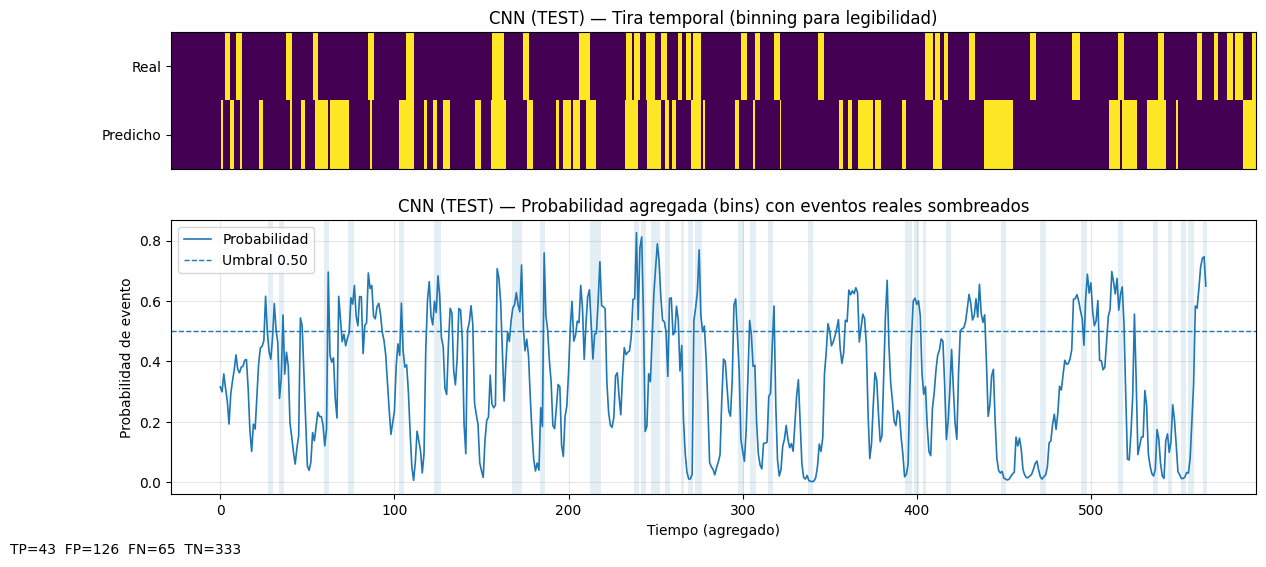

In [ ]:
# === CNN ===
try:
    _y_true = y_true_cnn if 'y_true_cnn' in locals() else np.array(y_te).ravel().astype(int)
    _probs  = probs_cnn  if 'probs_cnn'  in locals() else model.predict(te_inputs, verbose=0).ravel()
    _idx    = y_te.index if hasattr(y_te, "index") else None
    plot_timeline_legible(_y_true, _probs, title="CNN (TEST)", idx=_idx, thr=0.5, bins_target=600)
except Exception as e:
    print("CNN: no pude graficar ->", e)